In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('urban_lifestyle_impact_dataset.csv')
df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   str    
 2   location_type             10000 non-null  str    
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   str    
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   str    
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   str    
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  str    
dtypes: bool(2), float6

In [4]:
df.describe()

,daily_travel_time,nearby_industries,home_air_quality,noise_pollution_level,years_in_location,pollution_exposure_score
count,8876.000000,9205.000000,10000.000000,10000.00000,9480.000000,10000.000000
mean,45.154439,1.987398,60.114330,50.12037,20.623312,44.092933
std,19.892298,1.416077,15.158124,20.04742,11.558152,12.071672
min,0.000000,0.000000,0.000000,0.00000,1.000000,5.970000
25%,31.600000,1.000000,49.800000,36.80000,11.000000,35.517500
50%,45.000000,2.000000,60.200000,50.10000,21.000000,43.690000
75%,58.525000,3.000000,70.500000,63.60000,31.000000,52.010000
max,123.500000,10.000000,100.000000,100.00000,40.000000,100.000000


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = ['daily_travel_time', 'nearby_industries', 'home_air_quality', 'noise_pollution_level', 'years_in_location']
categorical_columns = ['vehicle_ownership', 'location_type', 'green_space_access', 'work_location_type', 'awareness_level']

num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_columns),
    ('cat', cat_transformer, categorical_columns)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X, y = df.drop(columns=['risk_category', 'pollution_exposure_score']), df['pollution_exposure_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search_params = {
    'regressor__fit_intercept': [True, False],
}
grid_search = GridSearchCV(estimator=pipeline, param_grid=grid_search_params, cv=5, scoring='r2', n_jobs=-1, verbose=2, error_score='raise')
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R2 score: {grid_search.best_score_:.4f}")
print(f"Test set R2 score with best parameters: {grid_search.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END ......................regressor__fit_intercept=True; total time=   0.9s
[CV] END .....................regressor__fit_intercept=False; total time=   1.3s
[CV] END .....................regressor__fit_intercept=False; total time=   1.8s
[CV] END ......................regressor__fit_intercept=True; total time=   1.4s
[CV] END .....................regressor__fit_intercept=False; total time=   1.7s
[CV] END ......................regressor__fit_intercept=True; total time=   2.2s
[CV] END .....................regressor__fit_intercept=False; total time=   1.6s
[CV] END ......................regressor__fit_intercept=True; total time=   2.2s
[CV] END ......................regressor__fit_intercept=True; total time=   2.1s
[CV] END .....................regressor__fit_intercept=False; total time=   2.2s
Best parameters: {'regressor__fit_intercept': True}
Best R2 score: 0.8207
Test set R2 score with best parameters: 0.8084


In [6]:
pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__fit_intercept,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.514957,0.465028,0.242967,0.061029,True,{'regressor__fit_intercept': True},0.824158,0.833278,0.811372,0.820737,0.813950,0.820699,0.007781,1
1,1.390125,0.300879,0.343400,0.111320,False,{'regressor__fit_intercept': False},0.095937,0.071697,0.010946,0.030863,0.045782,0.051045,0.029949,2


Mean Squared Error: 28.2686


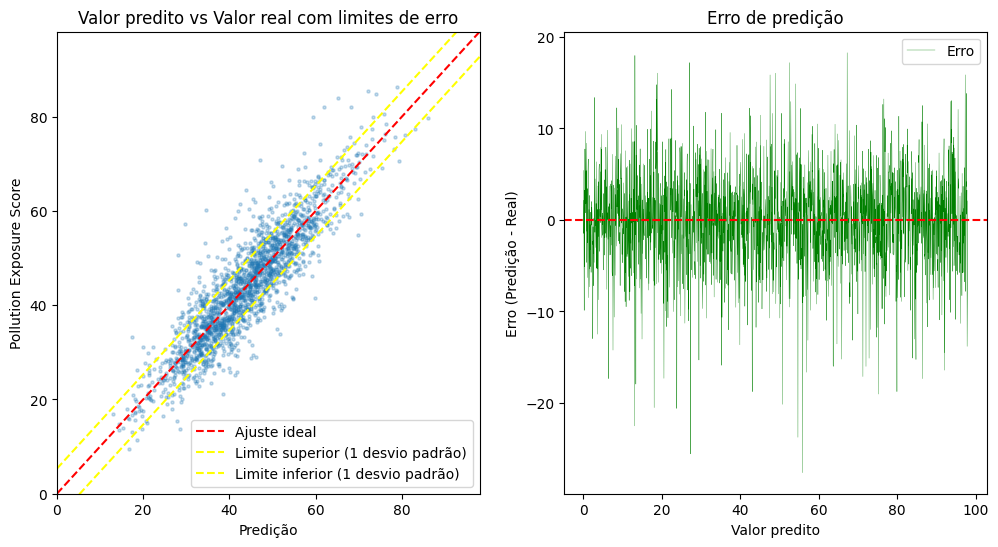

In [11]:

preds = grid_search.predict(X_test)

lims = (0, int(max(np.max(preds), np.max(y_test))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(preds, y_test, alpha=0.25, s=5)

x = np.linspace(lims[0], lims[1], len(y_test))
ax1.plot(x, x, color='red', linestyle='--', label='Ajuste ideal')

error = preds - y_test
mse = np.mean(error ** 2)
print(f'Mean Squared Error: {mse:.4f}')
ax1.plot(x, x + np.sqrt(mse), color='yellow', linestyle='--', label='Limite superior (1 desvio padrão)')
ax1.plot(x, x - np.sqrt(mse), color='yellow', linestyle='--', label='Limite inferior (1 desvio padrão)')

ax1.legend()
ax1.set_xlim(lims[0], lims[1])
ax1.set_ylim(lims[0], lims[1])
ax1.set_xlabel('Predição')
ax1.set_ylabel('Pollution Exposure Score')
ax1.set_title('Valor predito vs Valor real com limites de erro')

ax2.plot(x, error, color='green', linestyle='-', label='Erro', linewidth=0.25)
ax2.axhline(0, color='red', linestyle='--')
ax2.legend()
ax2.set_xlabel('Valor predito')
ax2.set_ylabel('Erro (Predição - Real)')
ax2.set_title('Erro de predição')

plt.show()